# Dataset Comparison: Raw vs Cleaned vs Transformed

This notebook showcases the differences between the raw dataset, the cleaned dataset, and the fully transformed dataset visually, highlighting the value added at each stage.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")

# Load the datasets
raw_path = '../data/raw/CGD_Dataset_before_cleaning.csv'
cleaned_path = '../data/processed/CGD_Dataset_after_cleaning.csv'
transformed_path = '../data/processed/CGD_Transformation_Final.csv'

df_raw = pd.read_csv(raw_path)
df_cleaned = pd.read_csv(cleaned_path)
df_transformed = pd.read_csv(transformed_path, low_memory=False)

print(f"Raw dataset shape: {df_raw.shape}")
print(f"Cleaned dataset shape: {df_cleaned.shape}")
print(f"Transformed dataset shape: {df_transformed.shape}")

Raw dataset shape: (6501, 16)
Cleaned dataset shape: (6312, 17)
Transformed dataset shape: (6311, 83)


## 1. Data Quality & Deduplication (Raw vs Cleaned)

Visualizing the reduction in duplicated rows and missing values after the cleaning process.

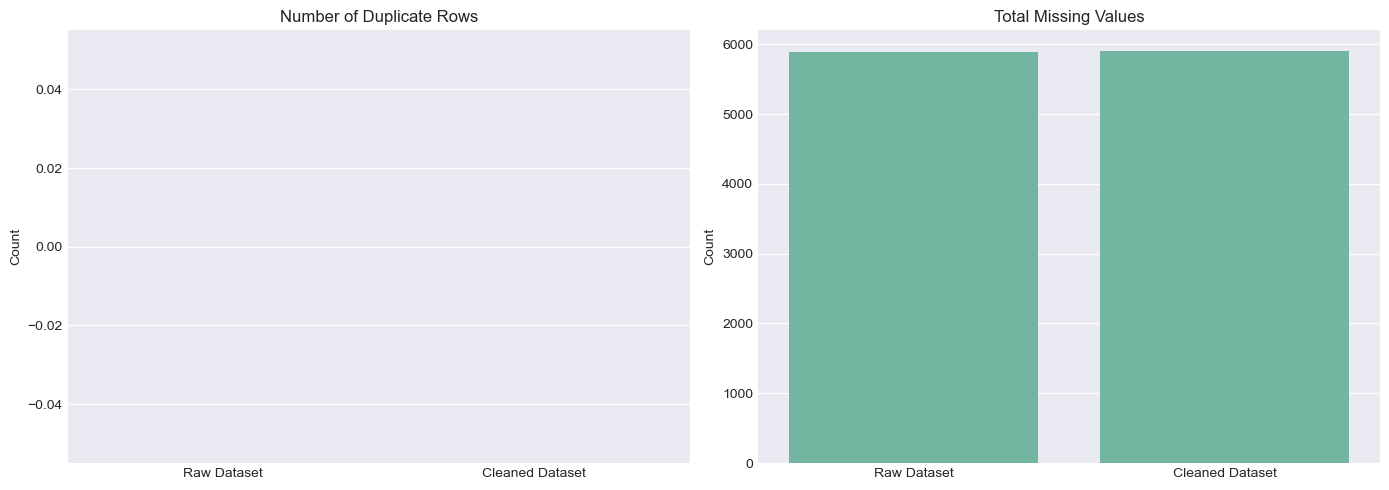

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Duplicated rows
raw_dups = df_raw.duplicated().sum()
clean_dups = df_cleaned.duplicated().sum()
sns.barplot(x=['Raw Dataset', 'Cleaned Dataset'], y=[raw_dups, clean_dups], ax=axes[0])
axes[0].set_title('Number of Duplicate Rows')
axes[0].set_ylabel('Count')

# Plot 2: Missing Values
raw_missing = df_raw.isnull().sum().sum()
clean_missing = df_cleaned.isnull().sum().sum()
sns.barplot(x=['Raw Dataset', 'Cleaned Dataset'], y=[raw_missing, clean_missing], ax=axes[1])
axes[1].set_title('Total Missing Values')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

## 2. Feature Dimension Growth (Raw vs Cleaned vs Transformed)

Showing how the number of features increases due to parsing and feature engineering.

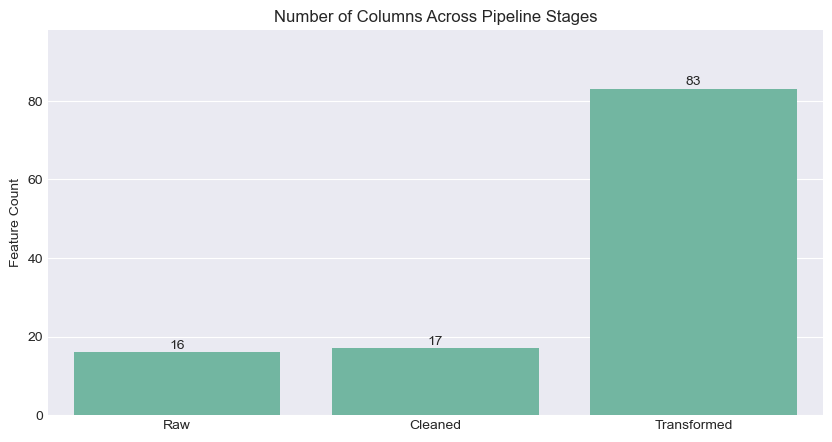

In [3]:
dims = [df_raw.shape[1], df_cleaned.shape[1], df_transformed.shape[1]]
stages = ['Raw', 'Cleaned', 'Transformed']

plt.figure(figsize=(10, 5))
ax = sns.barplot(x=stages, y=dims)
plt.title('Number of Columns Across Pipeline Stages')
plt.ylabel('Feature Count')
for i, v in enumerate(dims):
    ax.text(i, v + 1, str(v), ha='center')
plt.ylim(0, max(dims) + 15)
plt.show()

## 3. Feature Engineering for Leak Prevention (Cleaned vs Transformed)

The transformed dataset introduces flag mechanisms. Let us see the distribution of Leak Flags which were engineered.

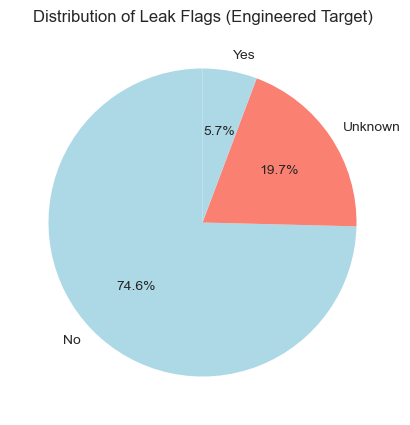

In [4]:
if 'Leak_Flag' in df_transformed.columns:
    plt.figure(figsize=(6, 5))
    leak_counts = df_transformed['Leak_Flag'].value_counts()
    plt.pie(leak_counts, labels=leak_counts.index, autopct='%1.1f%%', startangle=90, colors=['lightblue', 'salmon'])
    plt.title('Distribution of Leak Flags (Engineered Target)')
    plt.show()
else:
    print("Leak_Flag not found in transformed dataset.")

## 4. Temporal Analytics capabilities (Transformed)

Visualization of Flow measurements mapped across newly created time components like Hour and Season.

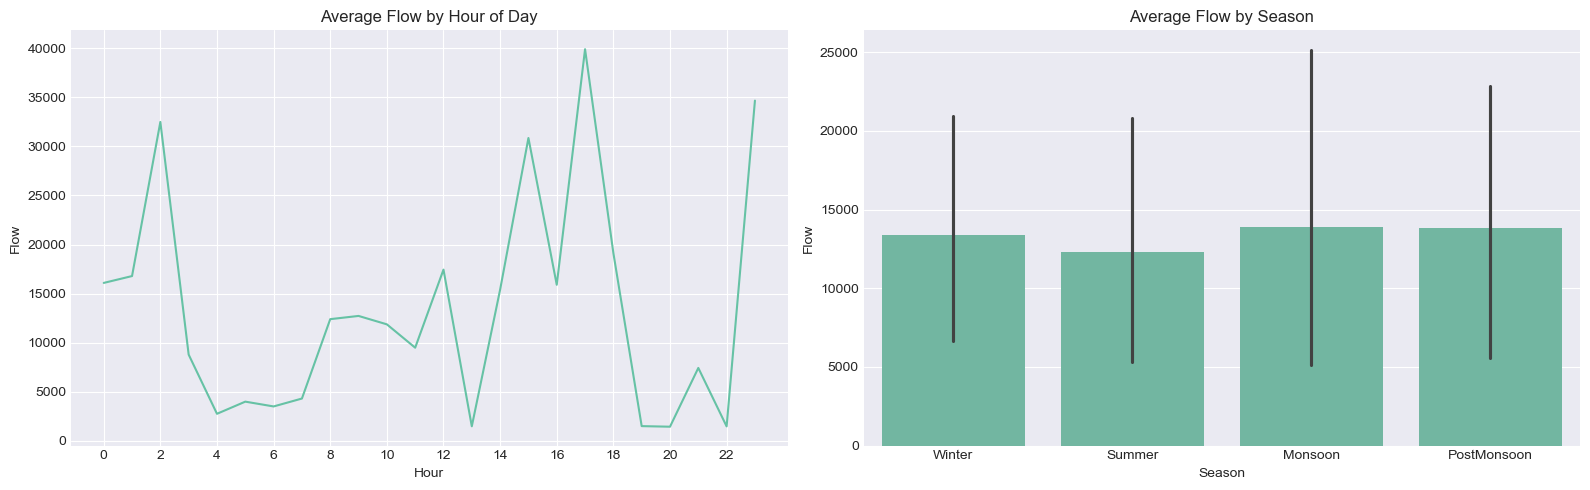

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

if 'Hour' in df_transformed.columns and 'Flow' in df_transformed.columns:
    sns.lineplot(data=df_transformed, x='Hour', y='Flow', ax=axes[0], errorbar=None)
    axes[0].set_title('Average Flow by Hour of Day')
    axes[0].set_xticks(range(0, 24, 2))
    
if 'Season' in df_transformed.columns and 'Flow' in df_transformed.columns:
    sns.barplot(data=df_transformed, x='Season', y='Flow', ax=axes[1])
    axes[1].set_title('Average Flow by Season')

plt.tight_layout()
plt.show()

## 5. Environmental Impact Calculations (Transformed)

Advanced use cases like Carbon Footprint calculation require new columns representing CO2 emissions built off the energy figures.

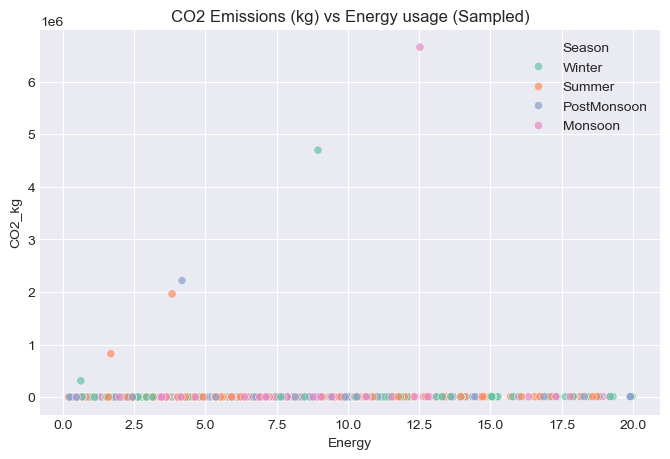

In [6]:
if 'CO2_kg' in df_transformed.columns and 'Energy' in df_transformed.columns:
    plt.figure(figsize=(8, 5))
    # Taking a sample of 1000 rows for scatter plot performance
    sample_df = df_transformed.sample(min(1000, len(df_transformed)), random_state=42)
    sns.scatterplot(data=sample_df, x='Energy', y='CO2_kg', hue='Season' if 'Season' in sample_df.columns else None, alpha=0.7)
    plt.title('CO2 Emissions (kg) vs Energy usage (Sampled)')
    plt.show()